# Task 2: Customer Segmentation Using Unsupervised Learning

## Objective: 

Cluster customers based on spending habits and propose marketing strategies tailored to each segment.

## Introduction

Customer segmentation is a key technique used by businesses to understand different groups of customers based on their behavior. By grouping customers with similar characteristics, companies can design more effective marketing strategies.

In this project, we use unsupervised learning techniques to segment customers based on their income and spending behavior using the Mall Customers dataset.

## Problem Statement

The objective of this project is to segment customers into distinct groups based on their spending habits and income levels using clustering techniques.

Since there is no predefined target variable, unsupervised learning (K-Means Clustering) is used to discover hidden patterns in the data.

The results will help businesses understand customer behavior and design targeted marketing strategies for each segment.

## Dataset Description

The dataset used is the Mall Customers dataset, which contains information about customers visiting a shopping mall.

Key features include:

- CustomerID: Unique identifier for each customer  
- Gender: Gender of the customer  
- Age: Age of the customer  
- Annual Income (k$): Annual income of the customer  
- Spending Score (1-100): Score assigned based on customer behavior and spending nature  

For clustering, the most relevant features are:
- Annual Income  
- Spending Score  

These features help identify different customer segments based on purchasing behavior.

## Import Libraries

In [2]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

## Load Dataset

In [3]:
df = pd.read_csv("Mall Customers Dataset.csv")

print("Shape:", df.shape)
df.head()

Shape: (200, 10)


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Satisfaction,NOV,Name,Email address,Occupation
0,1,Male,19,15,39,70,44,Ashlee Rollins,krueger@me.com,Marketing Manager
1,2,Male,21,15,81,38,33,Muhammad Norman,cisugrad@me.com,Food Scientist
2,3,Female,20,16,6,91,14,Maya Holder,pakaste@live.com,Actor
3,4,Female,23,16,77,38,11,Areli Forbes,stefano@outlook.com,Accountant
4,5,Female,31,17,40,66,48,Devyn Velazquez,birddog@outlook.com,Ambulance Officer


## Data Exploration (EDA)

In [4]:
# Basic info
df.info()

# Check missing values
df.isnull().sum()

# Statistical summary
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
 5   Satisfaction            200 non-null    int64 
 6   NOV                     200 non-null    int64 
 7   Name                    200 non-null    object
 8   Email address           200 non-null    object
 9   Occupation              200 non-null    object
dtypes: int64(6), object(4)
memory usage: 15.8+ KB


,CustomerID,Age,Annual Income (k$),Spending Score (1-100),Satisfaction,NOV
count,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000,50.765000,25.485000
std,57.879185,13.969007,26.264721,25.823522,28.658617,14.418713
min,1.000000,18.000000,15.000000,1.000000,1.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000,28.000000,14.000000
50%,100.500000,36.000000,61.500000,50.000000,52.000000,26.000000
75%,150.250000,49.000000,78.000000,73.000000,76.250000,37.250000
max,200.000000,70.000000,137.000000,99.000000,99.000000,50.000000


### Distribution Plots

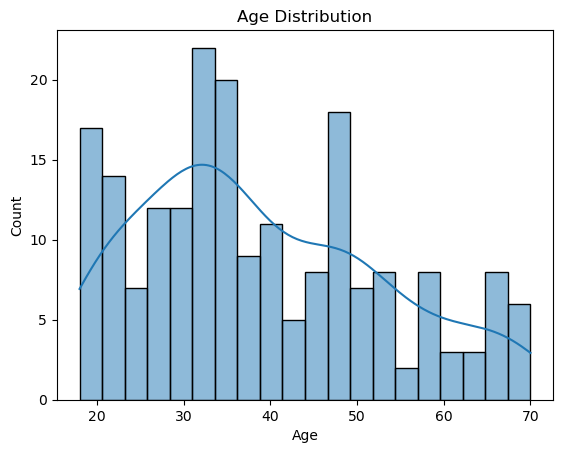

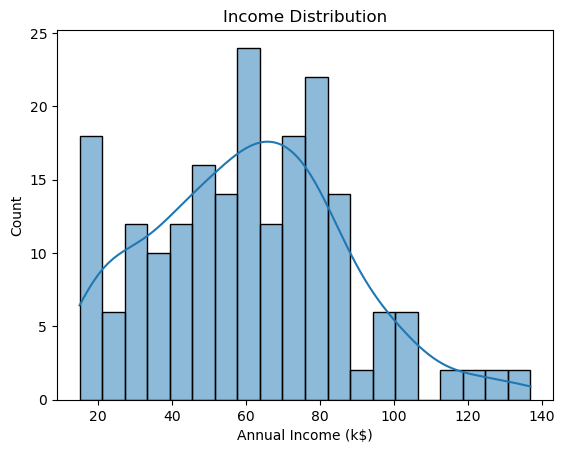

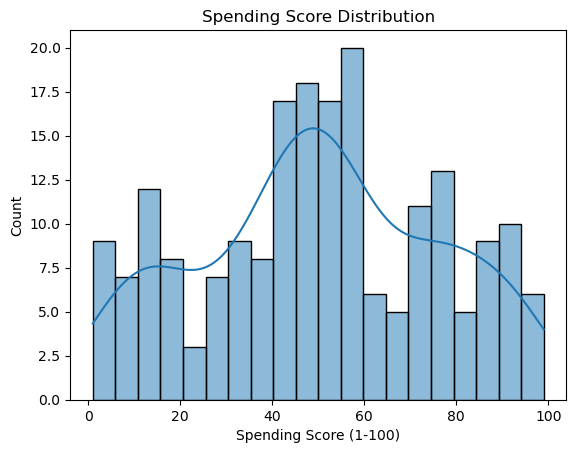

In [6]:
sns.histplot(df['Age'], bins=20, kde=True)
plt.title("Age Distribution")
plt.show()

sns.histplot(df['Annual Income (k$)'], bins=20, kde=True)
plt.title("Income Distribution")
plt.show()

sns.histplot(df['Spending Score (1-100)'], bins=20, kde=True)
plt.title("Spending Score Distribution")
plt.show()

### Relationship Plot

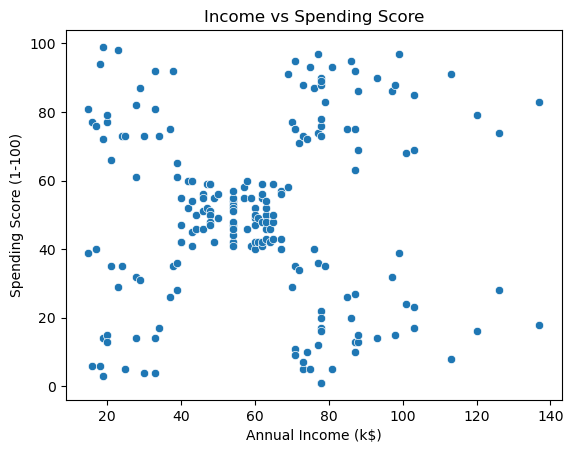

In [7]:
sns.scatterplot(
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    data=df
)
plt.title("Income vs Spending Score")
plt.show()

##  Data Preprocessing

In [9]:
# Select relevant features
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

# Standardize data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## Finding Optimal Clusters (Elbow Method)

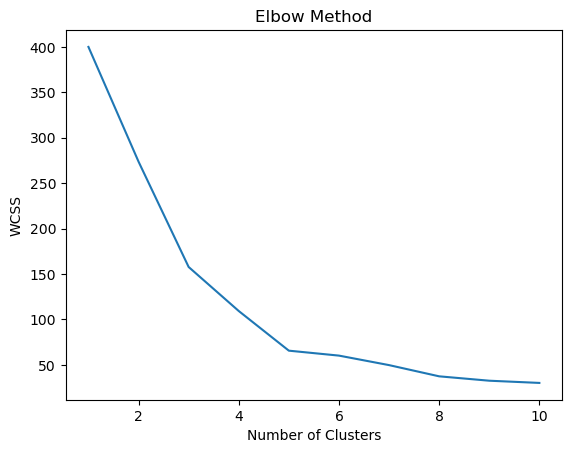

In [11]:
import warnings
import os

# Set environment variable to handle the KMeans threading warning
os.environ['OMP_NUM_THREADS'] = '1'

# Filter out user warnings
warnings.filterwarnings('ignore')

wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,11), wcss)
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

## K-Means Clustering Model

In [12]:
# Apply KMeans
kmeans = KMeans(n_clusters=5, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Satisfaction,NOV,Name,Email address,Occupation,Cluster
0,1,Male,19,15,39,70,44,Ashlee Rollins,krueger@me.com,Marketing Manager,4
1,2,Male,21,15,81,38,33,Muhammad Norman,cisugrad@me.com,Food Scientist,2
2,3,Female,20,16,6,91,14,Maya Holder,pakaste@live.com,Actor,4
3,4,Female,23,16,77,38,11,Areli Forbes,stefano@outlook.com,Accountant,2
4,5,Female,31,17,40,66,48,Devyn Velazquez,birddog@outlook.com,Ambulance Officer,4


## Cluster Visualization

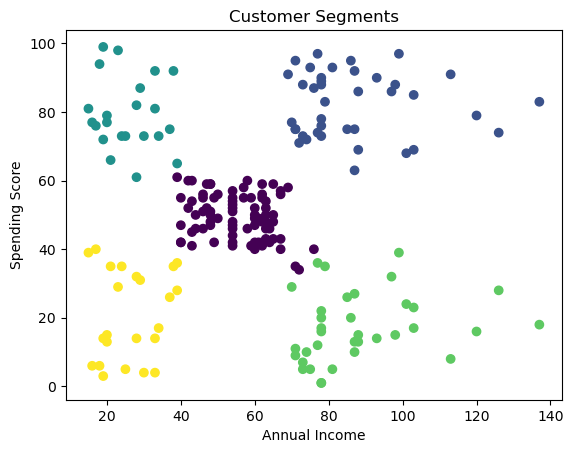

In [13]:
plt.scatter(
    df['Annual Income (k$)'],
    df['Spending Score (1-100)'],
    c=df['Cluster'],
    cmap='viridis'
)

plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Customer Segments")
plt.show()

## PCA for Visualization

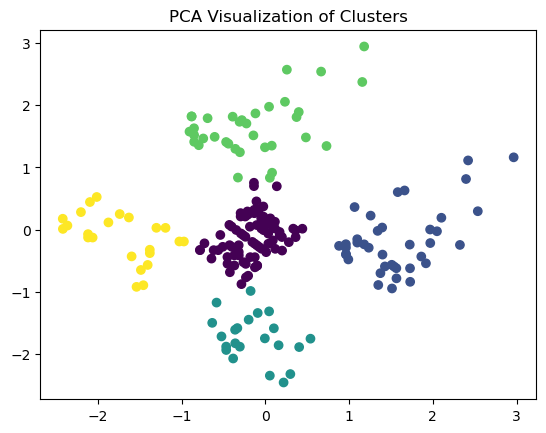

In [14]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.scatter(X_pca[:,0], X_pca[:,1], c=df['Cluster'], cmap='viridis')
plt.title("PCA Visualization of Clusters")
plt.show()

## Model Insights


- K-Means clustering successfully grouped customers into distinct segments based on income and spending behavior.

- The Elbow Method suggested an optimal number of clusters for segmentation.

- Clear separation between clusters indicates meaningful grouping of customer types.

- PCA visualization confirmed that clusters are well distributed in reduced dimensions.

- Customers with similar financial behavior were grouped together effectively.

## Business Insights


- High-income, high-spending customers are premium customers and should be targeted with exclusive offers.

- High-income, low-spending customers represent an opportunity for marketing campaigns to increase engagement.

- Low-income, high-spending customers may respond well to discounts and promotions.

- Low-income, low-spending customers require cost-effective marketing strategies.

- Customer segmentation enables personalized marketing, improving customer satisfaction and business revenue.

## Conclusion

This project demonstrates how unsupervised learning can be used to identify customer segments based on behavioral data. By applying K-Means clustering and PCA, meaningful patterns were discovered, enabling better understanding of customer groups.

These insights can help businesses design targeted marketing strategies and improve overall decision-making.